[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Tommy-Burns/easy-eo/blob/main/examples/01_fundamentals/02_clip_and_mosaic.ipynb)

# Clipping and mosaicking

Two spatial operations that bracket most workflows: cut a scene down to the area
you care about, and stitch neighbouring tiles into one raster.

- **Data:** the bundled Sentinel-2 sample and its region-of-interest polygon
- **Network:** only for the first download of the sample

Keep the two ideas distinct: **mosaic** merges rasters side by side in *space*;
**stack** (a separate operation, covered in
[05_stacking_bands](05_stacking_bands.ipynb)) layers *bands* on the same
footprint.

In [ ]:
# Running in Colab? Install Easy-EO. Does nothing anywhere else.
import sys

if "google.colab" in sys.modules:
    %pip install -q "easy-eo"


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

# Keeps the figures stored in this notebook small; raise it for print-quality output.
plt.rcParams["figure.dpi"] = 80

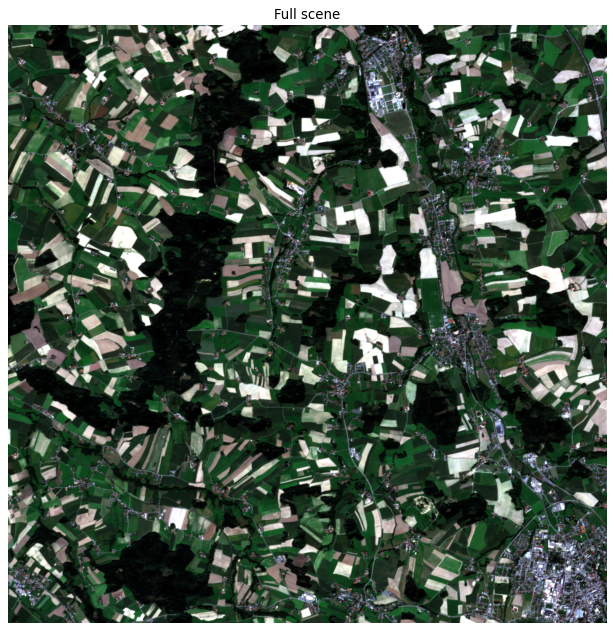

In [2]:
import geopandas as gpd

from eeo import load_raster
from eeo.datasets import load_sample_dataset

sd = load_sample_dataset()
scene = load_raster(sd.sentinel2_stacked)

scene.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="Full scene")

## Clipping to a vector boundary

The sample ships a region-of-interest polygon. Read it with GeoPandas - it is a GeoPackage, not a raster.

crs      : EPSG:4326
features : 1
bounds   : [13.37759291 48.22470172 13.4658428  48.27635016]


<Axes: >

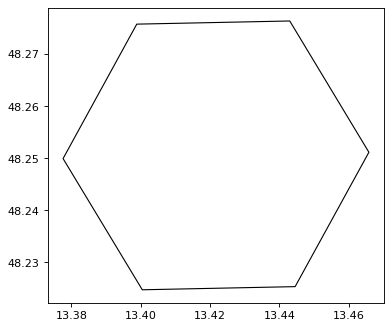

In [3]:
roi = gpd.read_file(sd.boundary)

print("crs      :", roi.crs)
print("features :", len(roi))
print("bounds   :", roi.total_bounds)
roi.plot(edgecolor="black", facecolor="none")

The ROI is in lon/lat (EPSG:4326) while the scene is in UTM zone 33N - Easy-EO reprojects the geometry onto the raster's CRS for you, so mismatched CRSs are not an error here.

before : (1024, 1024)
after  : (568, 656)


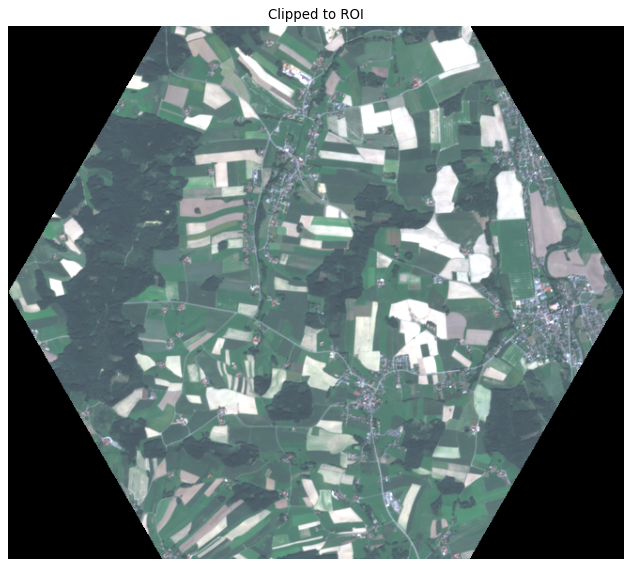

In [4]:
clipped = scene.clip_raster_with_vector(roi)

print("before :", scene.get_shape())
print("after  :", clipped.get_shape())
clipped.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="Clipped to ROI")

### Passing a path instead of a GeoDataFrame

A path to any vector file GeoPandas can read is accepted directly, which saves a line when you do not need the vector for anything else. Pass it as a string.

In [5]:
same = scene.clip_raster_with_vector(str(sd.boundary.path))
print("identical shape:", same.get_shape() == clipped.get_shape())
same.close()

identical shape: True


### crop, invert, all_touched

Three flags cover most of what you need:

- `crop=True` (default) shrinks the output to the geometry's bounding box. `crop=False` keeps the original extent and simply masks outside the polygon.
- `invert=True` masks *inside* the polygon instead - useful for excluding an area.
- `all_touched=True` keeps every pixel the geometry touches, rather than only those whose centre falls inside it.

crop=True   : (568, 656) (shrunk to the polygon's bounding box)
crop=False  : (1024, 1024) (original extent, outside masked)
invert=True : (1024, 1024) (inside masked instead)


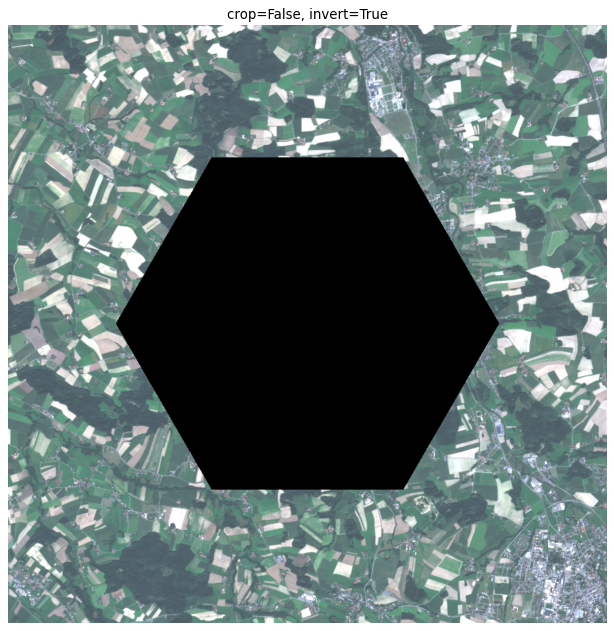

In [6]:
masked_only = scene.clip_raster_with_vector(roi, crop=False)
inverted = scene.clip_raster_with_vector(roi, crop=False, invert=True)

print("crop=True   :", clipped.get_shape(), "(shrunk to the polygon's bounding box)")
print("crop=False  :", masked_only.get_shape(), "(original extent, outside masked)")
print("invert=True :", inverted.get_shape(), "(inside masked instead)")

inverted.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="crop=False, invert=True")

### Counting what is left

Clipping fills the outside with nodata rather than deleting it, so measure area from the valid pixels.

In [7]:
import numpy as np

band = clipped.get_band("red").astype("float32")
nodata = clipped.get_metadata()["nodata"]
valid = np.isfinite(band) & (band != nodata)

pixel_area = abs(clipped.get_transform().a * clipped.get_transform().e)
print(f"valid pixels : {valid.sum():,}")
print(f"area         : {valid.sum() * pixel_area / 1e6:.2f} km^2")

valid pixels : 279,112
area         : 27.91 km^2


## Clipping to a bounding box

When you already know the coordinates, a bounding box skips the vector entirely. It is given in the **raster's own CRS** as `(minx, miny, maxx, maxy)`.

shape: (400, 400)


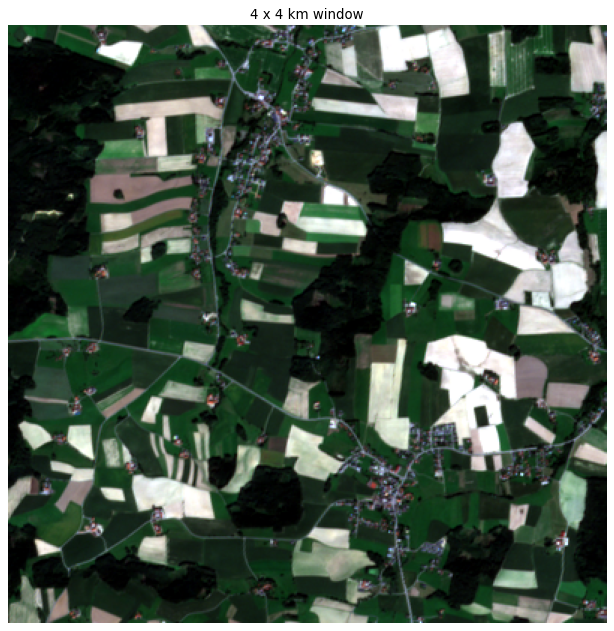

In [8]:
bounds = scene.get_bounds()
centre_x = (bounds.left + bounds.right) / 2
centre_y = (bounds.bottom + bounds.top) / 2

bbox = (centre_x - 2000, centre_y - 2000, centre_x + 2000, centre_y + 2000)   # 4 x 4 km

window = scene.clip_raster_with_bbox(bbox)
print("shape:", window.get_shape())
window.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="4 x 4 km window")

## Mosaicking

`mosaic` merges rasters that sit next to each other in space into a single raster covering their combined extent.

The sample is one scene, so to demonstrate honestly we first cut it into two overlapping halves, write them out as separate files, and then put them back together — exactly the shape of the real problem, where two tiles arrive as two files.

In [9]:
import tempfile
from pathlib import Path

out_dir = Path(tempfile.mkdtemp())

mid_x = (bounds.left + bounds.right) / 2
overlap = 800   # metres of deliberate overlap between the two tiles

west = scene.clip_raster_with_bbox((bounds.left, bounds.bottom, mid_x + overlap, bounds.top))
east = scene.clip_raster_with_bbox((mid_x - overlap, bounds.bottom, bounds.right, bounds.top))

west.save_raster(str(out_dir / "tile_west.tif"))
east.save_raster(str(out_dir / "tile_east.tif"))

print("west:", west.get_shape(), west.get_bounds())
print("east:", east.get_shape(), east.get_bounds())

west: (1024, 592) BoundingBox(left=377720.0, bottom=5340230.0, right=383640.0, top=5350470.0)
east: (1024, 592) BoundingBox(left=382040.0, bottom=5340230.0, right=387960.0, top=5350470.0)


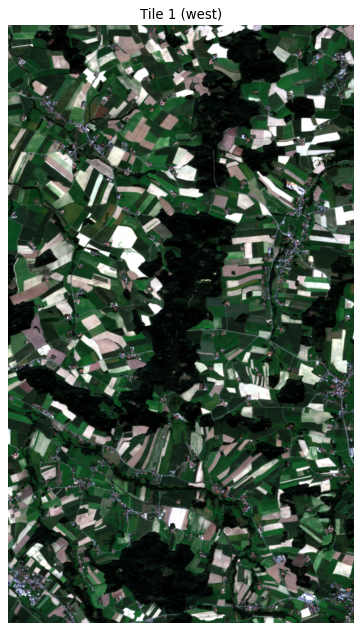

In [10]:
tile_west = load_raster(out_dir / "tile_west.tif")
tile_east = load_raster(out_dir / "tile_east.tif")

tile_west.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="Tile 1 (west)")

Now merge them. Band names survive the merge, and the output covers the union of the inputs' extents.

tile 1 : (1024, 592)
tile 2 : (1024, 592)
mosaic : (1024, 1024) ['blue', 'green', 'red', 'nir']
bounds : BoundingBox(left=377720.0, bottom=5340230.0, right=387960.0, top=5350470.0)


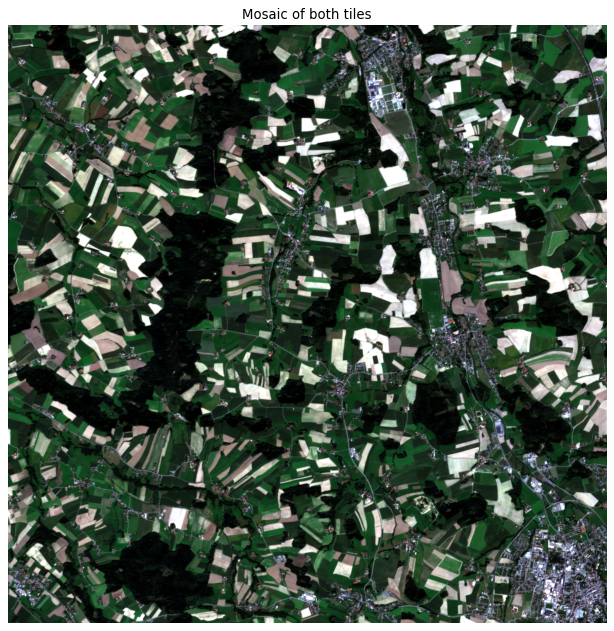

In [11]:
merged = tile_west.mosaic(tile_east, resampling_method="bilinear")

print("tile 1 :", tile_west.get_shape())
print("tile 2 :", tile_east.get_shape())
print("mosaic :", merged.get_shape(), merged.band_names)
print("bounds :", merged.get_bounds())

merged.plot_composite(["red", "green", "blue"], pmin=2, pmax=98, title="Mosaic of both tiles")

The mosaic is the same size as the scene we cut the tiles from - the round trip closed.

In [12]:
print("original scene:", scene.get_shape())
print("reconstructed :", merged.get_shape())
print("bounds match  :", merged.get_bounds() == scene.get_bounds())

original scene: (1024, 1024)
reconstructed : (1024, 1024)
bounds match  : True


### More than two, and mismatched CRSs

`mosaic` takes any iterable of datasets, and by default reprojects inputs whose CRS differs from the first one (`auto_reproject=True`). Pass `auto_reproject=False` to require an exact match and raise instead.

```python
merged = tiles[0].mosaic(tiles[1:], resampling_method="bilinear")
```

Give it `save_path=` to write straight to disk without holding the result.

In [13]:
for ds in (scene, clipped, masked_only, inverted, window, west, east, tile_west, tile_east, merged):
    ds.close()
print("closed")

closed


## Next

- **[03_reproject_and_resample](03_reproject_and_resample.ipynb)** - change CRS and pixel size
- **[05_stacking_bands](05_stacking_bands.ipynb)** - the *spectral* counterpart to mosaicking